In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [7]:
soccer_scores = pd.read_csv('../output/soccer_projII.csv')
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3
0,0,D1,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",1.004408,1.430743,1.231527
1,1,D1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1.000000,4.870410,5.208333
2,2,D1,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",1.000001,1.122188,1.445087
3,3,D1,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.007767,2.446390,1.108647
4,4,D1,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,1.874137,2.583979
...,...,...,...,...,...,...,...,...
1433,1433,SP1,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.000002,2.753724,3.891051
1434,1434,SP1,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",1.000053,34.116240,1.007049
1435,1435,SP1,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1.000000,24.207011,21.276596
1436,1436,SP1,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.000391,1.169291,1.694915


In [31]:
soccer_scores['League'] = soccer_scores['League'].replace("E0", "Premier_League")
soccer_scores['League'] = soccer_scores['League'].replace("D1", "Bundesliga")
soccer_scores['League'] = soccer_scores['League'].replace("SP1", "La_Liga")

In [33]:
soccer_scores['Team_Name'] = soccer_scores['Season'].astype(str) + ' ' + soccer_scores['Team']
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,Team_Name
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",1.004408,1.430743,1.231527,4.398380e-03,0.358194,0.208255,2000 Bayern Munich
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1.000000,4.870410,5.208333,3.725290e-09,1.583178,1.650260,2000 Bochum
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",1.000001,1.122188,1.445087,6.565887e-07,0.115280,0.368169,2000 Cottbus
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.007767,2.446390,1.108647,7.737202e-03,0.894614,0.103141,2000 Dortmund
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,1.874137,2.583979,3.360687e-07,0.628148,0.949331,2000 Ein Frankfurt
...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.000002,2.753724,3.891051,2.181350e-06,1.012954,1.358679,2024 Sociedad
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",1.000053,34.116240,1.007049,5.265548e-05,3.529774,0.007025,2024 Valencia
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1.000000,24.207011,21.276596,8.881784e-16,3.186642,3.057608,2024 Valladolid
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.000391,1.169291,1.694915,3.909534e-04,0.156398,0.527633,2024 Vallecano


In [35]:
us_league_scores = pd.read_csv('../output/us_leagues_projII.csv')
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",1.0,3.705717,1.092896
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",1.0,1.207999,1.488095
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",1.0,2.053641,1.210654
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",1.0,1.978912,1.231527
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.0,2.610411,4.329004
...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",1.0,1.215747,1.988072
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",1.0,8.020818,1.039501
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",1.0,66.410418,1.004016
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",1.0,3.078505,1.101322


# 1. Most extreme Collapses

## Soccer League

In [39]:
soccer_scores['log_c1'] = np.log(soccer_scores['c1'])
soccer_scores['log_c2'] = np.log(soccer_scores['c2'])
soccer_scores['log_c3'] = np.log(soccer_scores['c3'])

soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,Team_Name
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",1.004408,1.430743,1.231527,4.398380e-03,0.358194,0.208255,2000 Bayern Munich
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1.000000,4.870410,5.208333,3.725290e-09,1.583178,1.650260,2000 Bochum
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",1.000001,1.122188,1.445087,6.565887e-07,0.115280,0.368169,2000 Cottbus
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.007767,2.446390,1.108647,7.737202e-03,0.894614,0.103141,2000 Dortmund
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,1.874137,2.583979,3.360687e-07,0.628148,0.949331,2000 Ein Frankfurt
...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.000002,2.753724,3.891051,2.181350e-06,1.012954,1.358679,2024 Sociedad
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",1.000053,34.116240,1.007049,5.265548e-05,3.529774,0.007025,2024 Valencia
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1.000000,24.207011,21.276596,8.881784e-16,3.186642,3.057608,2024 Valladolid
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.000391,1.169291,1.694915,3.909534e-04,0.156398,0.527633,2024 Vallecano


In [51]:
top20_c1 = soccer_scores.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
top20_c2 = soccer_scores.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
top20_c3 = soccer_scores.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

top20_c1

,Season,League,Team_Name,log_c1
424,2023,Bundesliga,2023 Leverkusen,inf
511,2003,Premier_League,2003 Arsenal,inf
1348,2020,La_Liga,2020 Leganes,inf
70,2003,Bundesliga,2003 Werder Bremen,0.959617
1038,2004,La_Liga,2004 Barcelona,0.953758
840,2019,Premier_League,2019 Liverpool,0.946347
1278,2017,La_Liga,2017 Barcelona,0.946347
822,2018,Premier_League,2018 Liverpool,0.945451
1118,2009,La_Liga,2009 Barcelona,0.920576
217,2012,Bundesliga,2012 Bayern Munich,0.919754


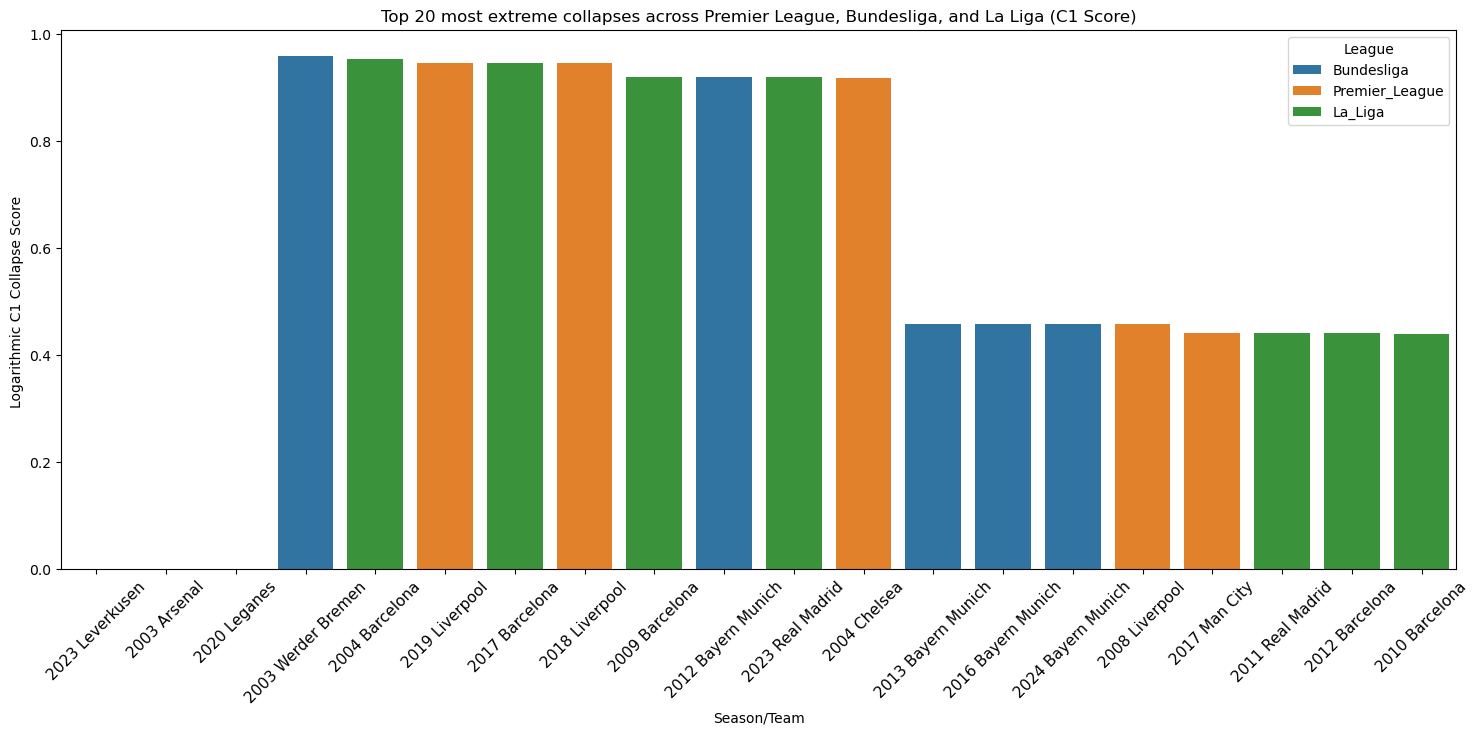

In [55]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c1['Team_Name'], y = top20_c1['log_c1'], palette = 'tab10', hue = top20_c1['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

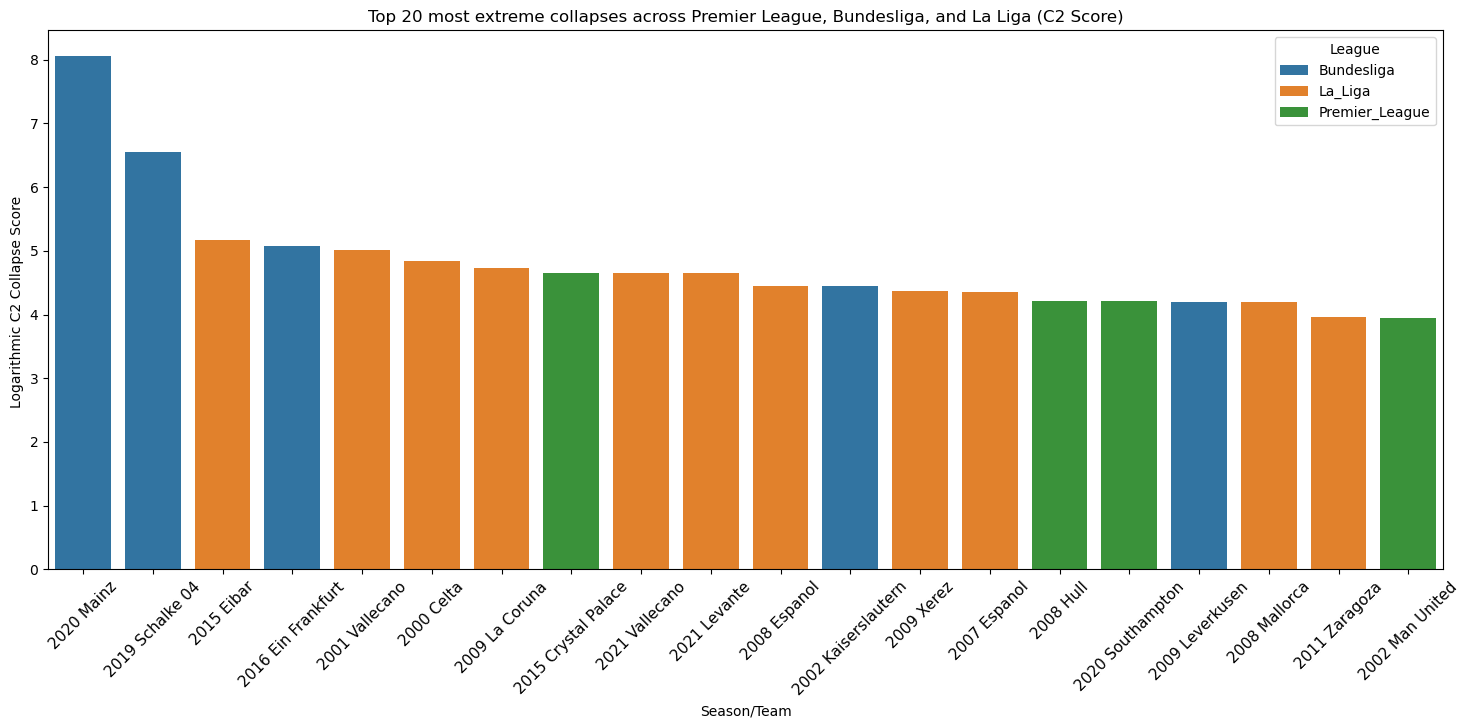

In [57]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c2['Team_Name'], y = top20_c2['log_c2'], palette = 'tab10', hue = top20_c2['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

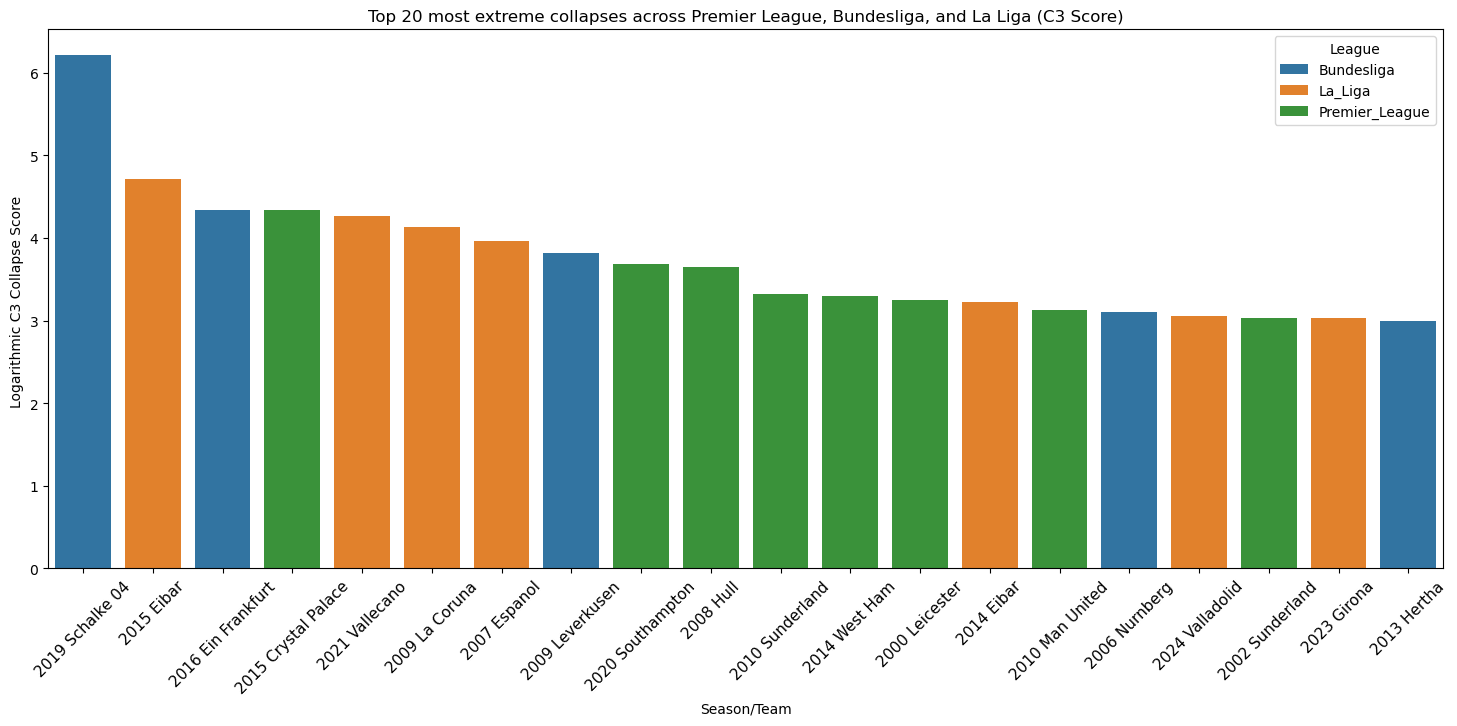

In [59]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c3['Team_Name'], y = top20_c3['log_c3'], palette = 'tab10', hue = top20_c3['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## US Leagues

In [66]:
us_league_scores['log_c1'] = us_league_scores.apply(lambda row: math.log(row['c1']), axis  = 1)
us_league_scores['log_c2'] = us_league_scores.apply(lambda row: math.log(row['c2']), axis  = 1)
us_league_scores['log_c3'] = us_league_scores.apply(lambda row: math.log(row['c3']), axis  = 1)

us_league_scores['formatted_team_name'] = us_league_scores.apply(lambda row: str(row['Season']) + ' ' + row['Team'], axis = 1)

us_league_scores['color'] = us_league_scores.apply(lambda row: "orange" if row['League'] == 'NBA' else 'blue', axis = 1)

In [68]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",1.0,3.705717,1.092896,-2.220446e-15,1.309877,0.088831,2015 Orlando Magic,orange
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",1.0,1.207999,1.488095,4.540812e-13,0.188966,0.397497,2015 Houston Rockets,orange
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",1.0,2.053641,1.210654,7.735748e-08,0.719614,0.191161,2015 Oklahoma City Thunder,orange
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",1.0,1.978912,1.231527,-4.440892e-16,0.682547,0.208255,2015 Sacramento Kings,orange
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.0,2.610411,4.329004,1.640910e-13,0.959508,1.465338,2015 Utah Jazz,orange
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",1.0,1.215747,1.988072,3.499526e-09,0.195359,0.687165,1991 Boston Celtics,orange
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",1.0,8.020818,1.039501,3.204326e-12,2.082040,0.038741,1991 Los Angeles Lakers,orange
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",1.0,66.410418,1.004016,2.220446e-15,4.195854,0.004008,1991 Denver Nuggets,orange
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",1.0,3.078505,1.101322,2.220446e-16,1.124444,0.096511,1991 Dallas Mavericks,orange


In [70]:
us_top20_c1 = us_league_scores.nlargest(20, "log_c1")[["Season", "League", "formatted_team_name", "log_c1"]]
us_top20_c2 = us_league_scores.nlargest(20, "log_c2")[["Season", "League", "formatted_team_name", "log_c2"]]
us_top20_c3 = us_league_scores.nlargest(20, "log_c3")[["Season", "League", "formatted_team_name", "log_c3"]]

us_top20_c1

,Season,League,formatted_team_name,log_c1
6,2015,NBA,2015 Golden State Warriors,0.008545
3163,1995,NBA,1995 Chicago Bulls,0.004845
2880,1996,NBA,1996 Chicago Bulls,0.000845
2700,1998,NBA,1998 Utah Jazz,0.000538
2717,1998,NBA,1998 San Antonio Spurs,0.000538
2558,2024,NBA,2024 Oklahoma City Thunder,0.000464
20,2015,NBA,2015 San Antonio Spurs,0.000253
2395,2016,NBA,2016 Golden State Warriors,0.000253
2634,1999,NBA,1999 Los Angeles Lakers,0.000253
2744,1985,NBA,1985 Boston Celtics,0.000253


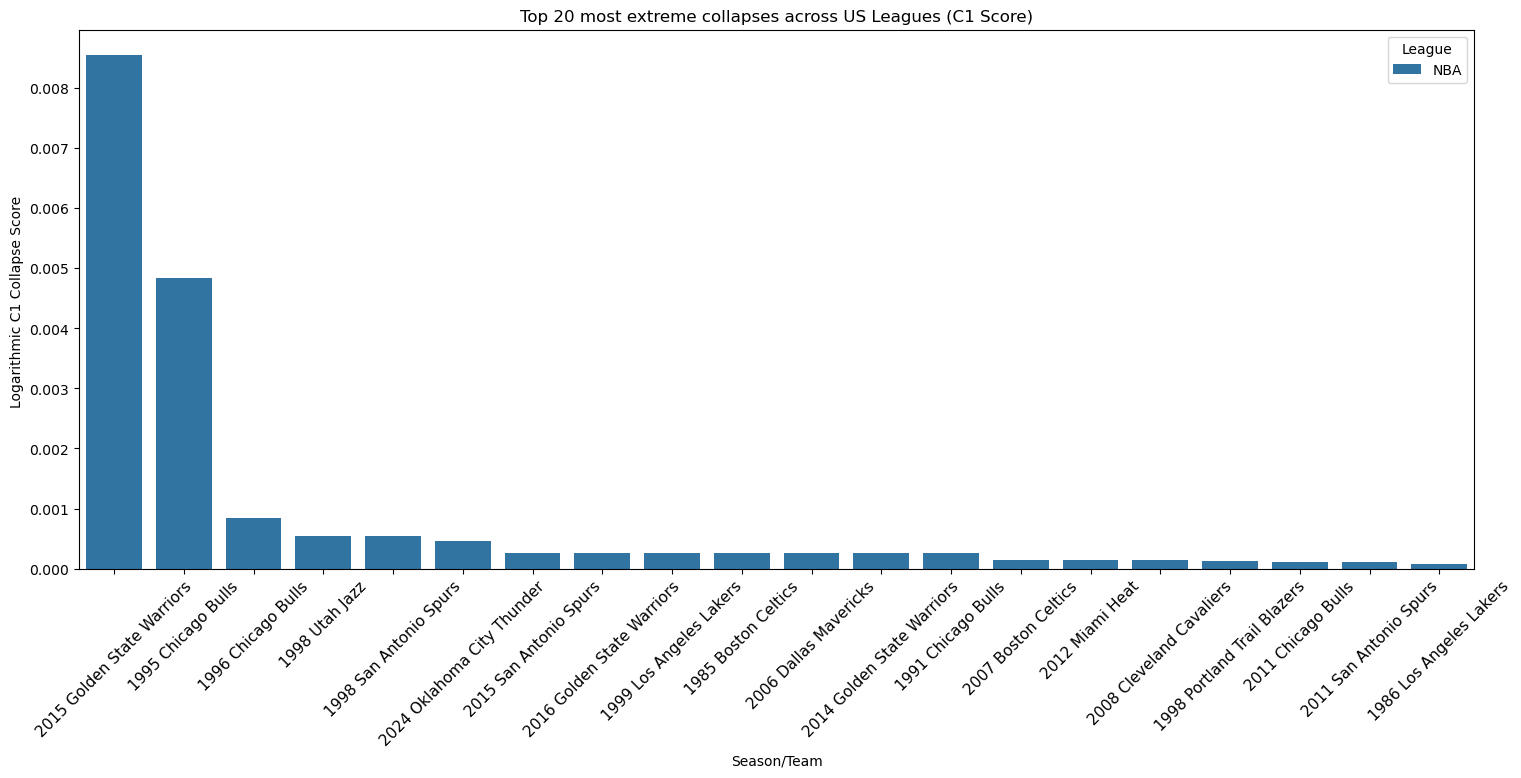

In [72]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c1['formatted_team_name'], y = us_top20_c1['log_c1'], palette = 'tab10', hue = us_top20_c1['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

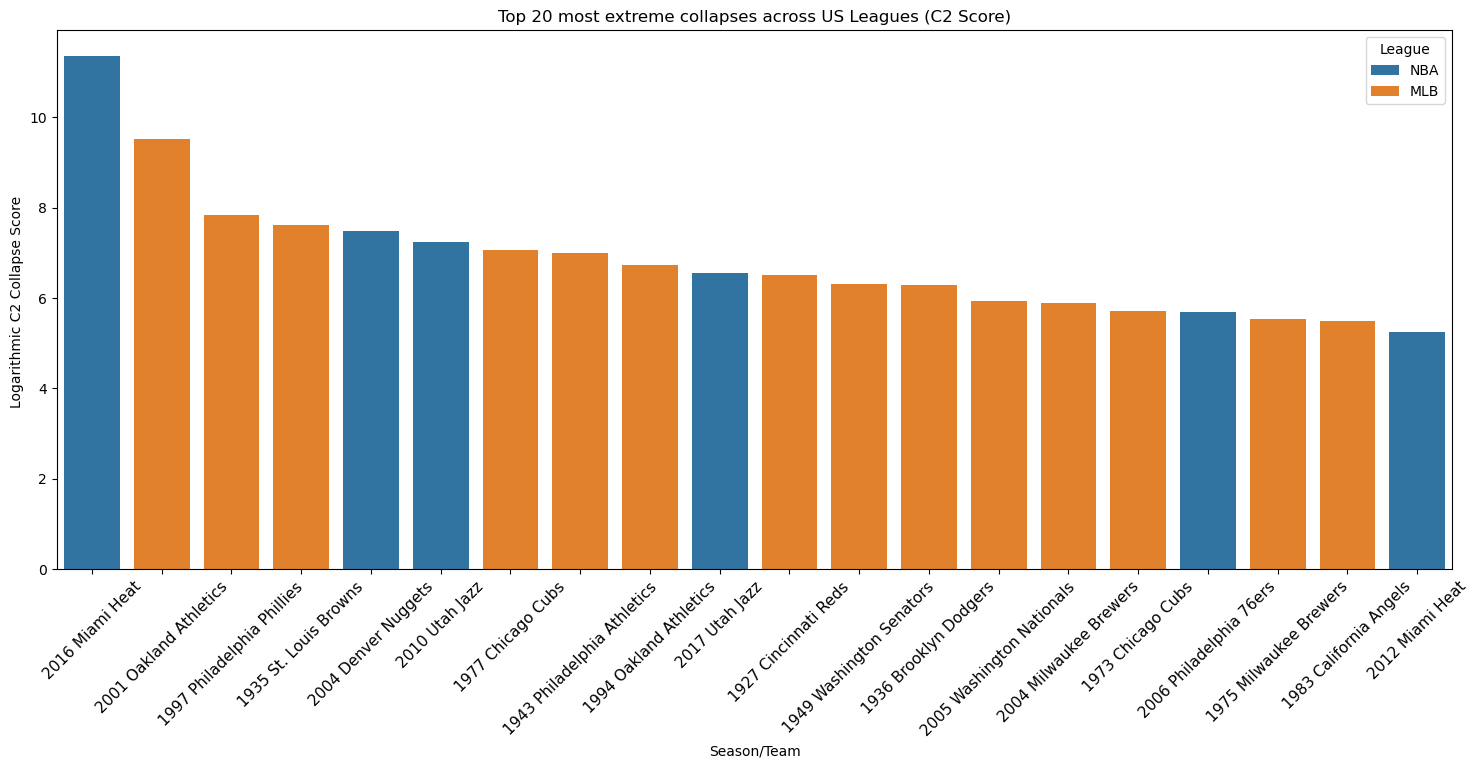

In [74]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c2['formatted_team_name'], y = us_top20_c2['log_c2'], palette = 'tab10', hue = us_top20_c2['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

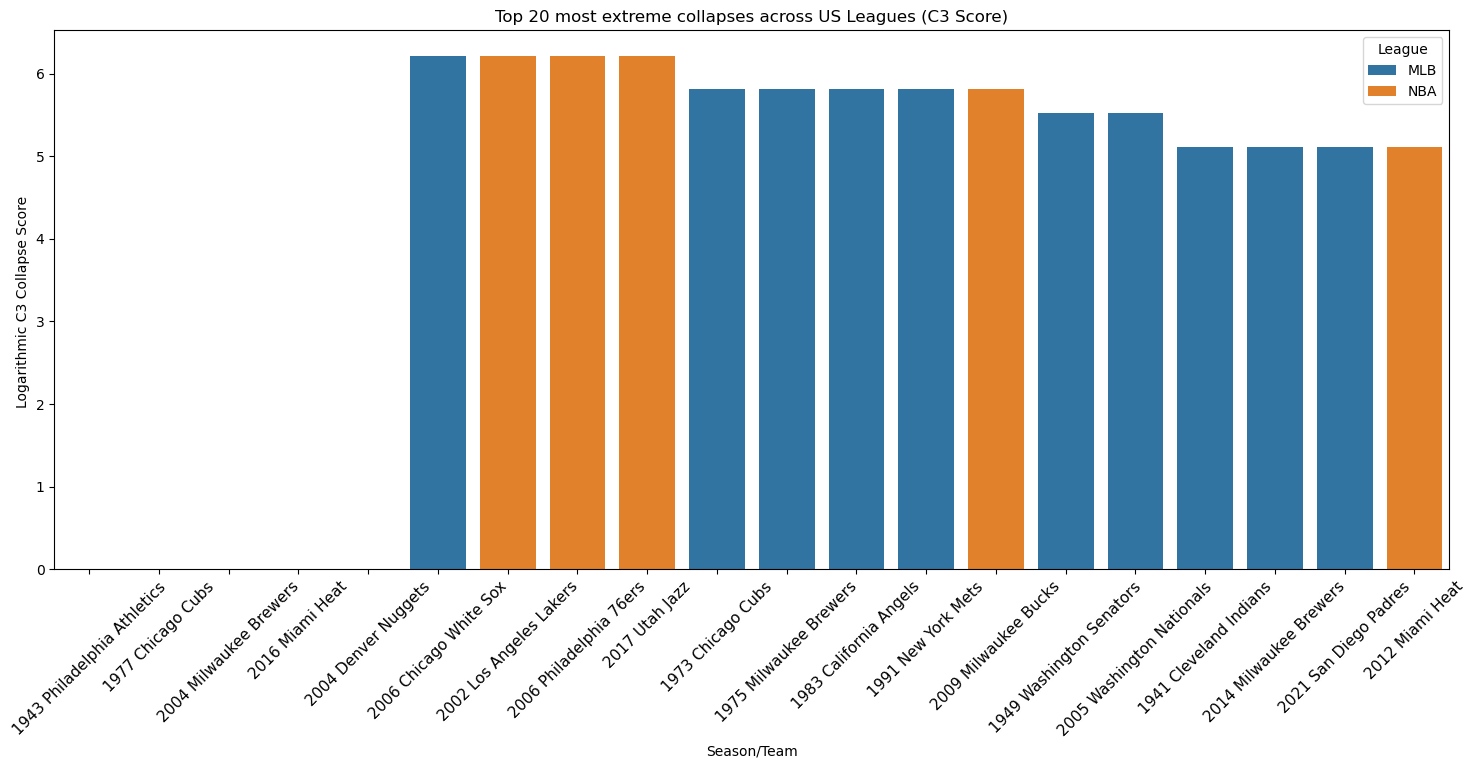

In [76]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c3['formatted_team_name'], y = us_top20_c3['log_c3'], palette = 'tab10', hue = us_top20_c3['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## US Leagues and Soccer Leagues Combined

In [81]:
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,Team_Name
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",1.004408,1.430743,1.231527,4.398380e-03,0.358194,0.208255,2000 Bayern Munich
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1.000000,4.870410,5.208333,3.725290e-09,1.583178,1.650260,2000 Bochum
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",1.000001,1.122188,1.445087,6.565887e-07,0.115280,0.368169,2000 Cottbus
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.007767,2.446390,1.108647,7.737202e-03,0.894614,0.103141,2000 Dortmund
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,1.874137,2.583979,3.360687e-07,0.628148,0.949331,2000 Ein Frankfurt
...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.000002,2.753724,3.891051,2.181350e-06,1.012954,1.358679,2024 Sociedad
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",1.000053,34.116240,1.007049,5.265548e-05,3.529774,0.007025,2024 Valencia
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1.000000,24.207011,21.276596,8.881784e-16,3.186642,3.057608,2024 Valladolid
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.000391,1.169291,1.694915,3.909534e-04,0.156398,0.527633,2024 Vallecano


In [85]:
us_league_scores['Team_Name'] = us_league_scores['formatted_team_name']

In [87]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color,Team_Name
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",1.0,3.705717,1.092896,-2.220446e-15,1.309877,0.088831,2015 Orlando Magic,orange,2015 Orlando Magic
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",1.0,1.207999,1.488095,4.540812e-13,0.188966,0.397497,2015 Houston Rockets,orange,2015 Houston Rockets
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",1.0,2.053641,1.210654,7.735748e-08,0.719614,0.191161,2015 Oklahoma City Thunder,orange,2015 Oklahoma City Thunder
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",1.0,1.978912,1.231527,-4.440892e-16,0.682547,0.208255,2015 Sacramento Kings,orange,2015 Sacramento Kings
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",1.0,2.610411,4.329004,1.640910e-13,0.959508,1.465338,2015 Utah Jazz,orange,2015 Utah Jazz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",1.0,1.215747,1.988072,3.499526e-09,0.195359,0.687165,1991 Boston Celtics,orange,1991 Boston Celtics
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",1.0,8.020818,1.039501,3.204326e-12,2.082040,0.038741,1991 Los Angeles Lakers,orange,1991 Los Angeles Lakers
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",1.0,66.410418,1.004016,2.220446e-15,4.195854,0.004008,1991 Denver Nuggets,orange,1991 Denver Nuggets
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",1.0,3.078505,1.101322,2.220446e-16,1.124444,0.096511,1991 Dallas Mavericks,orange,1991 Dallas Mavericks


In [91]:
combined_df = pd.concat([soccer_scores, us_league_scores], ignore_index=True)
combined_df

,Unnamed: 0,League,Season,Team,Sequence,c1,c2,c3,log_c1,log_c2,log_c3,Team_Name,formatted_team_name,color
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",1.004408,1.430743,1.231527,4.398380e-03,0.358194,0.208255,2000 Bayern Munich,NaN,NaN
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1.000000,4.870410,5.208333,3.725290e-09,1.583178,1.650260,2000 Bochum,NaN,NaN
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",1.000001,1.122188,1.445087,6.565887e-07,0.115280,0.368169,2000 Cottbus,NaN,NaN
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.007767,2.446390,1.108647,7.737202e-03,0.894614,0.103141,2000 Dortmund,NaN,NaN
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,1.874137,2.583979,3.360687e-07,0.628148,0.949331,2000 Ein Frankfurt,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",1.000000,1.215747,1.988072,3.499526e-09,0.195359,0.687165,1991 Boston Celtics,1991 Boston Celtics,orange
4933,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",1.000000,8.020818,1.039501,3.204326e-12,2.082040,0.038741,1991 Los Angeles Lakers,1991 Los Angeles Lakers,orange
4934,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",1.000000,66.410418,1.004016,2.220446e-15,4.195854,0.004008,1991 Denver Nuggets,1991 Denver Nuggets,orange
4935,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",1.000000,3.078505,1.101322,2.220446e-16,1.124444,0.096511,1991 Dallas Mavericks,1991 Dallas Mavericks,orange


In [95]:
combined__top20_c1 = combined_df.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
combined__top20_c2 = combined_df.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
combined__top20_c3 = combined_df.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

combined__top20_c1

,Season,League,Team_Name,log_c1
424,2023,Bundesliga,2023 Leverkusen,inf
511,2003,Premier_League,2003 Arsenal,inf
1348,2020,La_Liga,2020 Leganes,inf
70,2003,Bundesliga,2003 Werder Bremen,0.959617
1038,2004,La_Liga,2004 Barcelona,0.953758
840,2019,Premier_League,2019 Liverpool,0.946347
1278,2017,La_Liga,2017 Barcelona,0.946347
822,2018,Premier_League,2018 Liverpool,0.945451
1118,2009,La_Liga,2009 Barcelona,0.920576
217,2012,Bundesliga,2012 Bayern Munich,0.919754


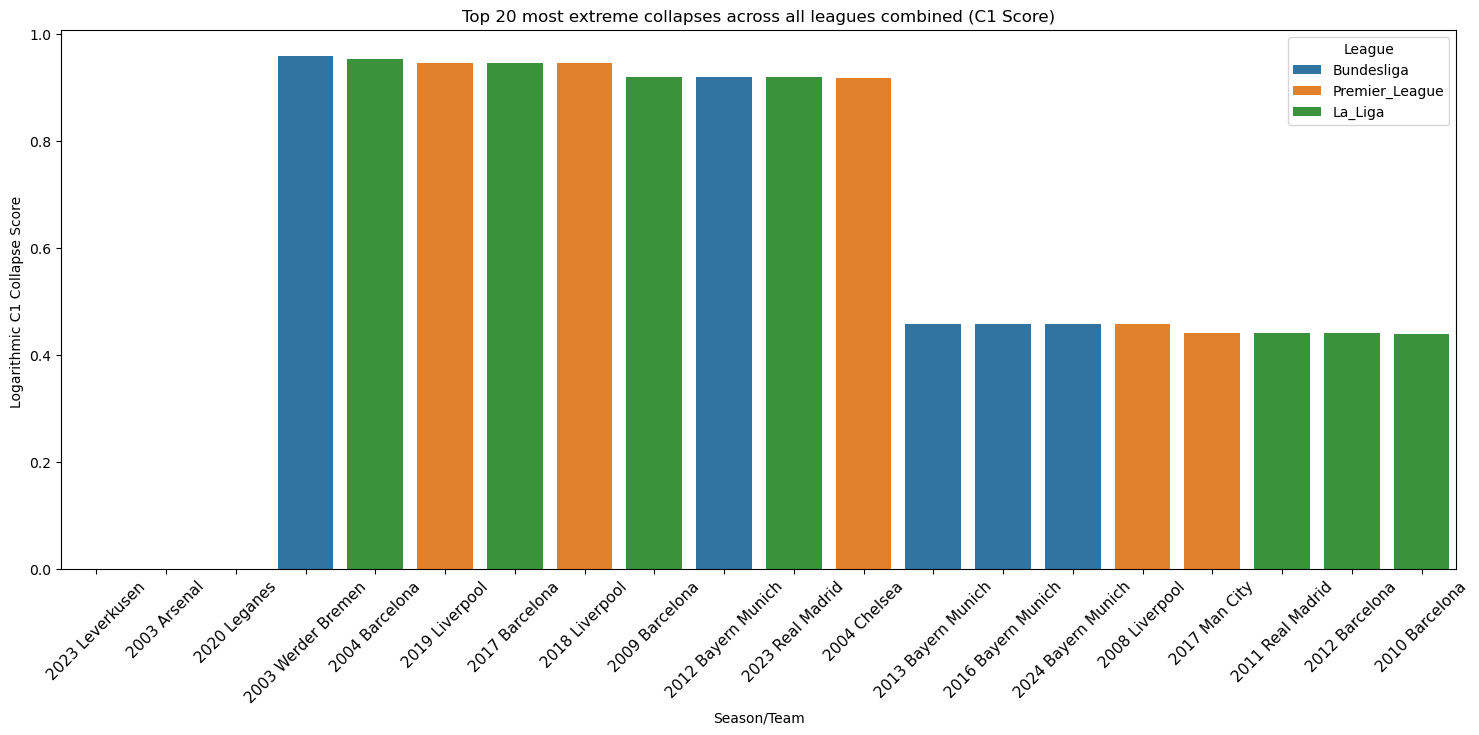

In [99]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c1['Team_Name'], y = combined__top20_c1['log_c1'], palette = 'tab10', hue = combined__top20_c1['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

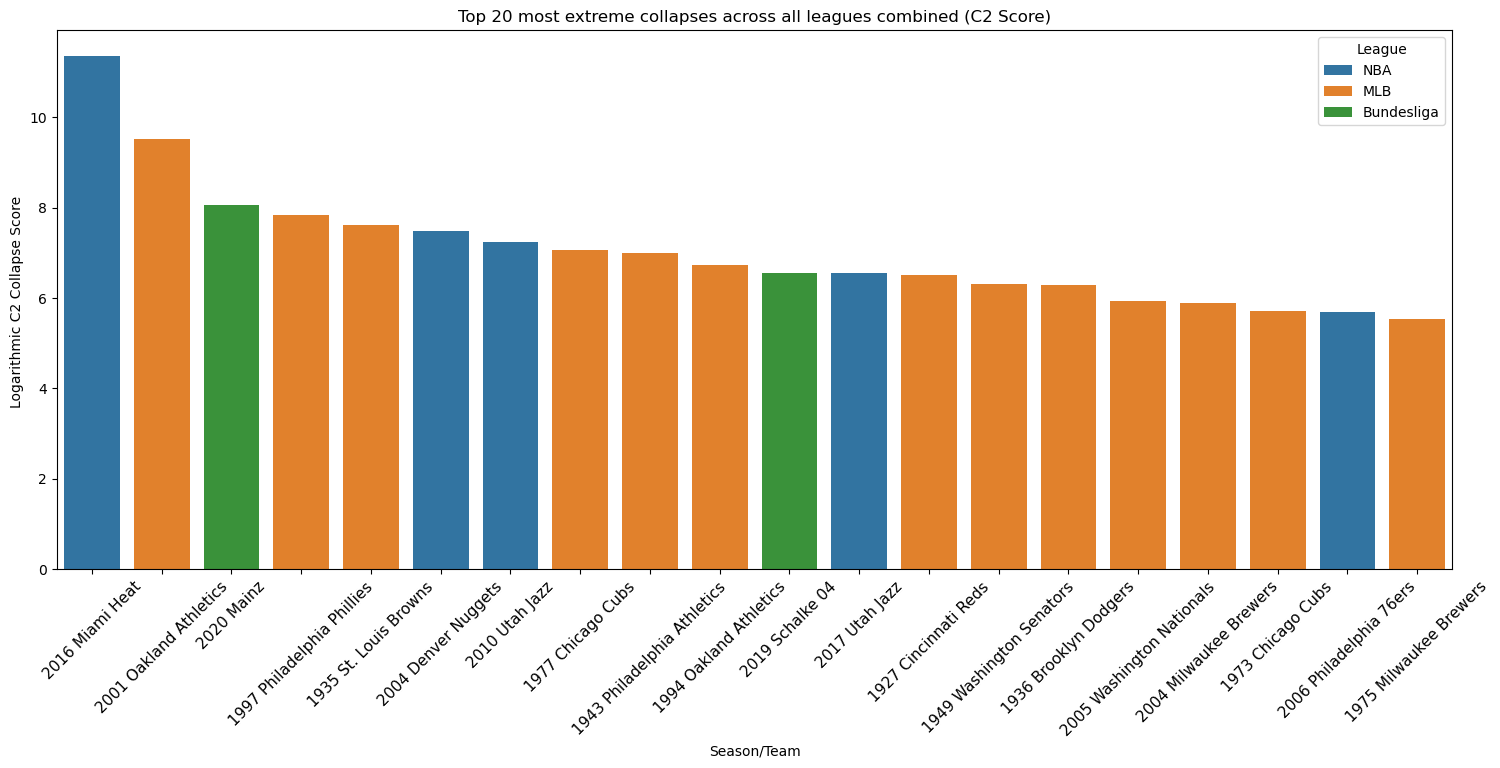

In [101]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c2['Team_Name'], y = combined__top20_c2['log_c2'], palette = 'tab10', hue = combined__top20_c2['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

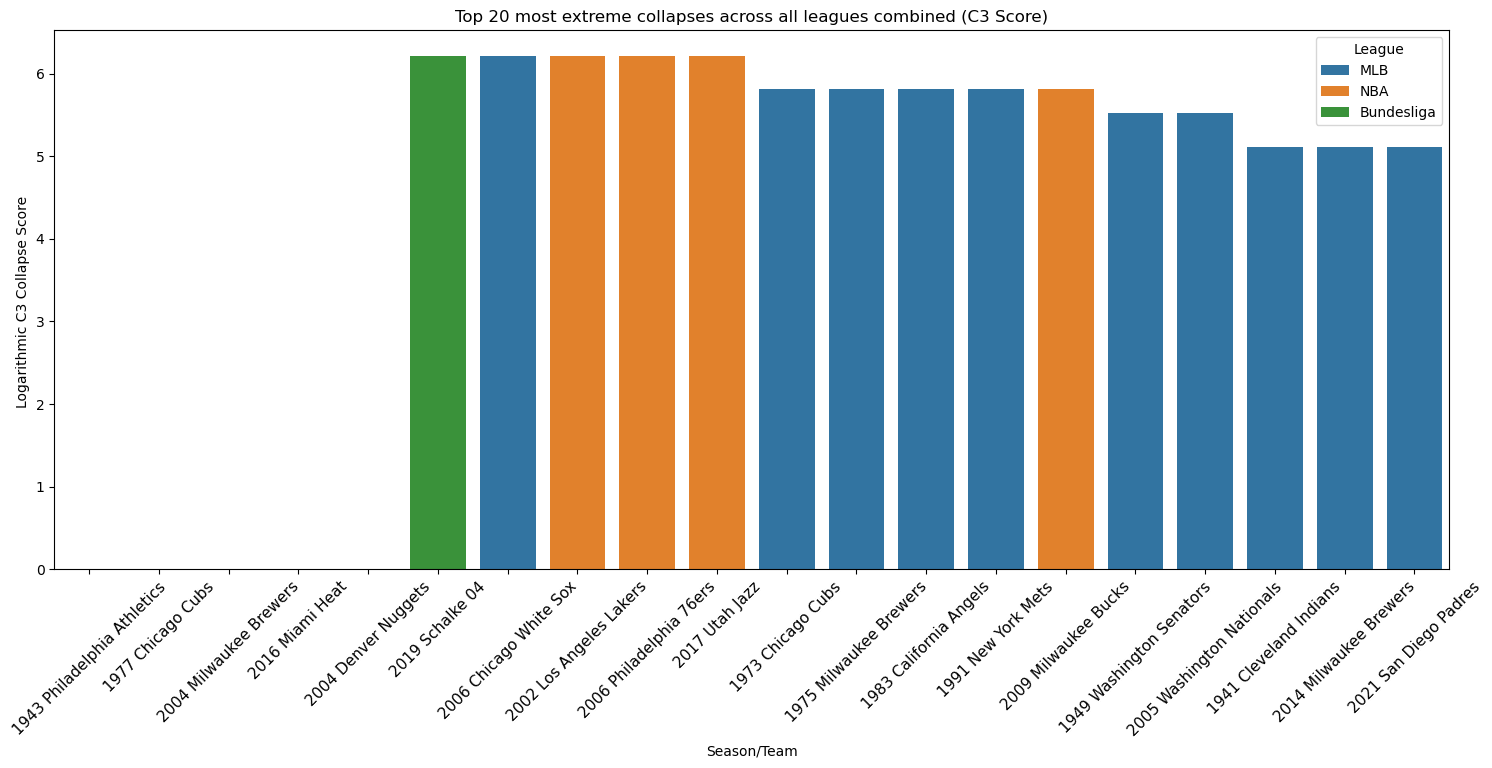

In [103]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c3['Team_Name'], y = combined__top20_c3['log_c3'], palette = 'tab10', hue = combined__top20_c3['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()